In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
from pathlib import Path

DATA_PATH = Path("../data/raw/train.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 913,000
Columns: 4
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [7]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("Stores:", df["store"].nunique())
print("Items:", df["item"].nunique())

Start date: 2013-01-01 00:00:00
End date: 2017-12-31 00:00:00
Stores: 10
Items: 50


In [10]:
df["sales"].describe()

count   913,000.00
mean         52.25
std          28.80
min           0.00
25%          30.00
50%          47.00
75%          70.00
max         231.00
Name: sales, dtype: float64

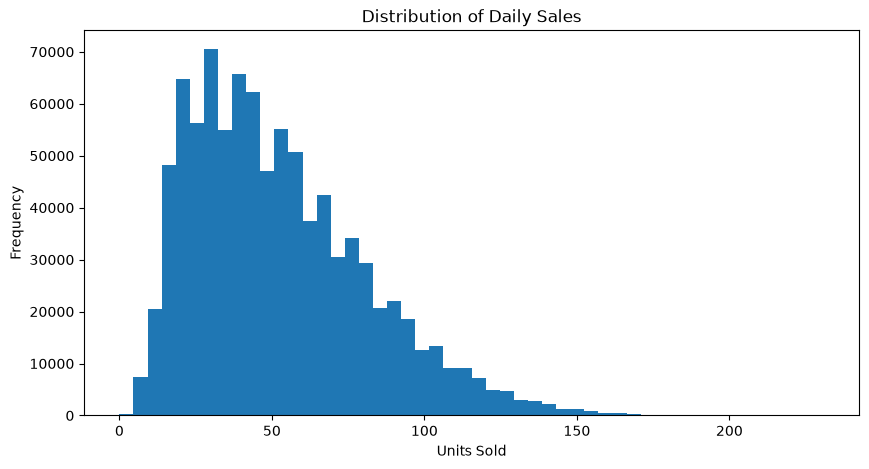

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(df["sales"], bins=50)

plt.title("Distribution of Daily Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

In [12]:
daily_sales = (
    df.groupby("date", as_index=False)["sales"]
      .sum()
)

daily_sales.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


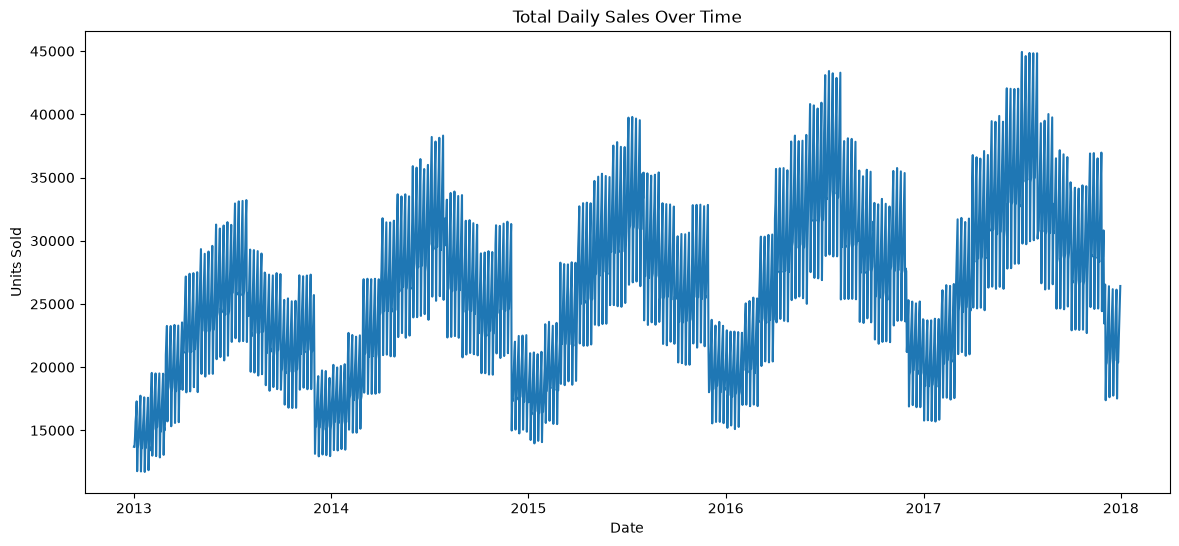

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

In [14]:
daily_sales["rolling_mean_30"] = (
    daily_sales["sales"]
    .rolling(window=30)
    .mean()
)

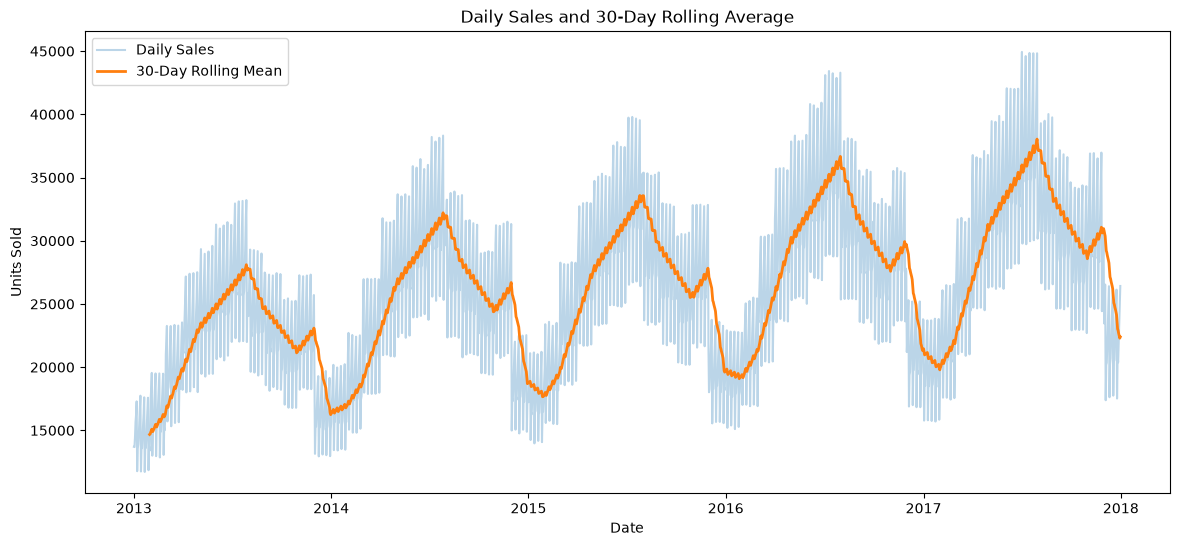

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    alpha=0.3,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_30"],
    linewidth=2,
    label="30-Day Rolling Mean"
)

plt.title("Daily Sales and 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

In [16]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [17]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1
